# Pavan S (24BAD085)

# Experiment 7 - Gaussian Mixture Model (GMM)


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score


In [9]:
df = pd.read_csv('/content/Mall_Customers.csv')
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [10]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [11]:
gmm = GaussianMixture(n_components=5, random_state=42)
gmm.fit(X_scaled)

labels = gmm.predict(X_scaled)
probs = gmm.predict_proba(X_scaled)

df['Cluster'] = labels

In [12]:
score = silhouette_score(X_scaled, labels)
print('Silhouette Score:', score)

Silhouette Score: 0.5536892843811245


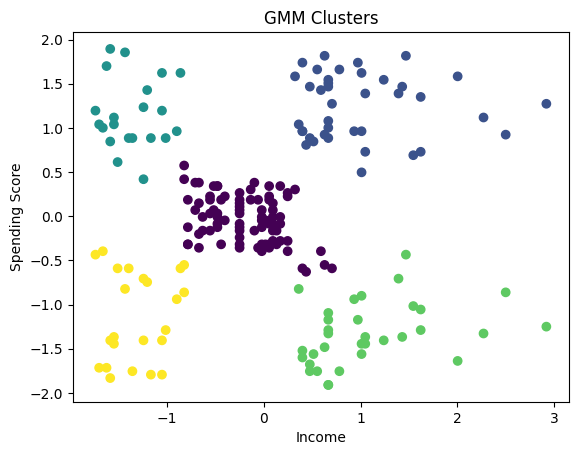

In [13]:
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=labels)
plt.title('GMM Clusters')
plt.xlabel('Income')
plt.ylabel('Spending Score')
plt.show()

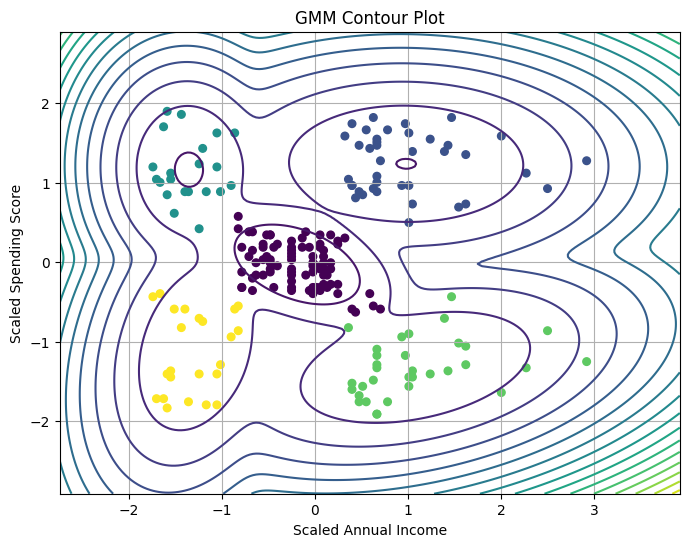

In [17]:
x = np.linspace(X_scaled[:, 0].min() - 1, X_scaled[:, 0].max() + 1, 200)
y = np.linspace(X_scaled[:, 1].min() - 1, X_scaled[:, 1].max() + 1, 200)

X_mesh, Y_mesh = np.meshgrid(x, y)
XX = np.array([X_mesh.ravel(), Y_mesh.ravel()]).T

Z = -gmm.score_samples(XX)
Z = Z.reshape(X_mesh.shape)

plt.figure(figsize=(8, 6))

plt.contour(X_mesh, Y_mesh, Z, levels=20)

plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels, s=30)

plt.title("GMM Contour Plot")
plt.xlabel("Scaled Annual Income")
plt.ylabel("Scaled Spending Score")
plt.grid(True)

plt.show()